In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# LangChain imports
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

print("✅ Libraries imported successfully!")

# Verify key packages
import langchain
import sentence_transformers
import faiss

print(f"\n📦 Package Versions:")
print(f"   LangChain: {langchain.__version__}")
print(f"   Sentence Transformers: {sentence_transformers.__version__}")
print(f"   FAISS: {faiss.__version__}")

✅ Libraries imported successfully!

📦 Package Versions:
   LangChain: 1.3.1
   Sentence Transformers: 5.5.1
   FAISS: 1.13.2


In [3]:
from pathlib import Path

# Create project directory
project_dir = Path(r'C:\Python\\ML Intro\\Projects\\Chat with Documents')
project_dir.mkdir(parents=True, exist_ok=True)

# Create all subdirectories
dirs = [
    'data/pdfs',
    'data/processed',
    'vector_store',
    'results/plots',
    'results/metrics',
    'notebooks',
    'models'
]

for d in dirs:
    (project_dir / d).mkdir(parents=True, exist_ok=True)
    
print(f"✅ Project structure created at: {project_dir}")
print("\n📁 Directory structure:")
for d in dirs:
    print(f"   ├── {d}/")

✅ Project structure created at: C:\Python\ML Intro\Projects\Chat with Documents

📁 Directory structure:
   ├── data/pdfs/
   ├── data/processed/
   ├── vector_store/
   ├── results/plots/
   ├── results/metrics/
   ├── notebooks/
   ├── models/


In [ ]:
import os
from pathlib import Path

# Create .env file with your Groq API key
project_dir = Path(r'C:\\Python\\ML Intro\\Projects\\Chat with Documents')

print("🔑 GROQ API KEY SETUP")
print("="*70)
print("\n📋 Steps to get your FREE Groq API key:")
print("   1. Go to: https://console.groq.com/keys")
print("   2. Sign up for FREE account")
print("   3. Click 'Create API Key'")
print("   4. Copy your API key")
print("   5. Paste it below")
print("="*70)

# Set your API key here
GROQ_API_KEY = "###########################################"  # Replace with your actual key

# Save to .env file
env_path = project_dir / '.env'
with open(str(env_path), 'w') as f:
    f.write(f"GROQ_API_KEY={GROQ_API_KEY}\n")

print(f"\n✅ API key saved to: {env_path}")

# Also set as environment variable
os.environ['GROQ_API_KEY'] = GROQ_API_KEY

# Test API key
from groq import Groq

try:
    client = Groq(api_key=GROQ_API_KEY)
    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": "Say 'API key works!'"}],
        max_tokens=20
    )
    print(f"\n✅ Groq API working!")
    print(f"   Response: {response.choices[0].message.content}")
    print(f"   Model: openai/gpt-oss-120b")
except Exception as e:
    print(f"\n❌ API Error: {e}")
    print("   Please check your API key")

🔑 GROQ API KEY SETUP

📋 Steps to get your FREE Groq API key:
   1. Go to: https://console.groq.com/keys
   2. Sign up for FREE account
   3. Click 'Create API Key'
   4. Copy your API key
   5. Paste it below

✅ API key saved to: C:\Python\ML Intro\Projects\Chat with Documents\.env

✅ Groq API working!
   Response: 
   Model: openai/gpt-oss-120b


In [9]:
import urllib.request
from pathlib import Path

project_dir = Path(r'C:\\Python\\ML Intro\\Projects\\Chat with Documents')
pdf_dir = project_dir / 'data' / 'pdfs'

print("📥 Sample PDFs for testing")
print("="*70)
print("\n💡 We need some PDFs to test our RAG system.")
print("\nOption A: Download free PDFs (recommended)")
print("   1. Go to: https://arxiv.org/")
print("   2. Download any research paper as PDF")
print("   3. Save to: " + str(pdf_dir))

print("\nOption B: Use your own PDFs")
print("   • Textbooks")
print("   • Research papers")
print("   • Company documents")
print("   • Study notes")

print("\nOption C: Create a sample PDF programmatically")

# Create a sample text file as placeholder
sample_text = """
ARTIFICIAL INTELLIGENCE: A COMPREHENSIVE OVERVIEW

Chapter 1: Introduction to Artificial Intelligence

Artificial Intelligence (AI) is the simulation of human intelligence processes
by computer systems. These processes include learning, reasoning, and self-correction.

Key Areas of AI:
1. Machine Learning - Systems that learn from data
2. Deep Learning - Neural networks with multiple layers
3. Natural Language Processing - Understanding human language
4. Computer Vision - Interpreting visual information
5. Robotics - Physical AI systems

Chapter 2: Machine Learning

Machine Learning is a subset of AI that enables systems to learn and improve
from experience without being explicitly programmed.

Types of Machine Learning:
- Supervised Learning: Learning from labeled data
- Unsupervised Learning: Finding patterns in unlabeled data
- Reinforcement Learning: Learning through rewards and penalties

Popular Machine Learning Algorithms:
1. Linear Regression
2. Decision Trees
3. Random Forest
4. Support Vector Machines
5. Neural Networks

Chapter 3: Deep Learning

Deep Learning uses artificial neural networks with multiple layers to
progressively extract higher-level features from raw input.

Applications of Deep Learning:
- Image Recognition
- Speech Recognition
- Natural Language Processing
- Medical Diagnosis
- Autonomous Driving

Chapter 4: Natural Language Processing

Natural Language Processing (NLP) is a branch of AI that helps computers
understand, interpret, and manipulate human language.

Key NLP Tasks:
1. Text Classification
2. Named Entity Recognition
3. Machine Translation
4. Question Answering
5. Text Summarization
6. Sentiment Analysis

Chapter 5: Applications of AI

AI is being applied across many industries:

Healthcare:
- Medical image analysis
- Drug discovery
- Patient diagnosis support

Finance:
- Fraud detection
- Algorithmic trading
- Credit scoring
- Risk assessment

Education:
- Personalized learning
- Automated grading
- Intelligent tutoring systems

Transportation:
- Self-driving vehicles
- Traffic optimization
- Route planning

Chapter 6: Future of AI

The future of AI includes:
- Artificial General Intelligence (AGI)
- Human-AI collaboration
- Explainable AI
- Edge AI
- Quantum AI

Challenges in AI:
1. Bias and fairness
2. Privacy concerns
3. Interpretability
4. Energy consumption
5. Safety and alignment
"""

# Save as text file (we'll convert to PDF)
sample_path = pdf_dir / 'ai_overview.txt'
with open(str(sample_path), 'w') as f:
    f.write(sample_text)

print(f"\n✅ Sample text saved to: {sample_path}")
print("\n📝 To convert to PDF:")
print("   Option 1: Copy text and paste into Word → Save as PDF")
print("   Option 2: Use online converter: https://smallpdf.com/txt-to-pdf")
print("   Option 3: Download a real PDF from arxiv.org")
print("\n💡 For now, we'll work with .txt files too!")

📥 Sample PDFs for testing

💡 We need some PDFs to test our RAG system.

Option A: Download free PDFs (recommended)
   1. Go to: https://arxiv.org/
   2. Download any research paper as PDF
   3. Save to: C:\Python\ML Intro\Projects\Chat with Documents\data\pdfs

Option B: Use your own PDFs
   • Textbooks
   • Research papers
   • Company documents
   • Study notes

Option C: Create a sample PDF programmatically

✅ Sample text saved to: C:\Python\ML Intro\Projects\Chat with Documents\data\pdfs\ai_overview.txt

📝 To convert to PDF:
   Option 1: Copy text and paste into Word → Save as PDF
   Option 2: Use online converter: https://smallpdf.com/txt-to-pdf
   Option 3: Download a real PDF from arxiv.org

💡 For now, we'll work with .txt files too!


In [11]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from pathlib import Path
import os

project_dir = Path(r'C:\\Python\\ML Intro\\Projects\\Chat with Documents')
pdf_dir = project_dir / 'data' / 'pdfs'

def load_document(file_path):
    """
    Load document from PDF or TXT file
    """
    file_path = Path(file_path)
    
    if file_path.suffix.lower() == '.pdf':
        # Load PDF
        loader = PyPDFLoader(str(file_path))
        pages = loader.load()
        print(f"   ✅ PDF loaded: {len(pages)} pages")
        return pages
    
    elif file_path.suffix.lower() == '.txt':
        # Load TXT file
        from langchain_community.document_loaders import TextLoader
        loader = TextLoader(str(file_path), encoding='utf-8')
        docs = loader.load()
        print(f"   ✅ TXT loaded: {len(docs)} documents")
        return docs
    
    else:
        print(f"   ❌ Unsupported file type: {file_path.suffix}")
        return []

# Load all documents in pdf directory
print("📥 Loading documents...")
print("="*70)

all_documents = []
doc_stats = []

for file_path in pdf_dir.iterdir():
    if file_path.suffix.lower() in ['.pdf', '.txt']:
        print(f"\n📄 Loading: {file_path.name}")
        docs = load_document(file_path)
        
        if docs:
            all_documents.extend(docs)
            
            # Get total content length
            total_chars = sum(len(doc.page_content) for doc in docs)
            
            doc_stats.append({
                'filename': file_path.name,
                'pages_chunks': len(docs),
                'total_characters': total_chars,
                'avg_chars_per_chunk': total_chars // len(docs)
            })

print(f"\n{'='*70}")
print(f"✅ DOCUMENT LOADING COMPLETE")
print(f"{'='*70}")
print(f"   Total documents loaded: {len(all_documents)}")
print(f"   Total characters: {sum(len(d.page_content) for d in all_documents):,}")

# Display stats
if doc_stats:
    stats_df = pd.DataFrame(doc_stats)
    print(f"\n📊 Document Statistics:")
    print(stats_df.to_string(index=False))

📥 Loading documents...

📄 Loading: ai_overview.txt
   ✅ TXT loaded: 1 documents

✅ DOCUMENT LOADING COMPLETE
   Total documents loaded: 1
   Total characters: 2,368

📊 Document Statistics:
       filename  pages_chunks  total_characters  avg_chars_per_chunk
ai_overview.txt             1              2368                 2368


In [12]:
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

def chunk_documents(documents, chunk_size=1000, chunk_overlap=200):
    """
    Split documents into smaller chunks for better retrieval
    
    Args:
        documents: List of LangChain documents
        chunk_size: Maximum characters per chunk
        chunk_overlap: Overlap between chunks
    
    Returns:
        List of chunked documents
    """
    
    # Create text splitter
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    
    # Split documents
    chunks = text_splitter.split_documents(documents)
    
    return chunks

# Chunk all documents
print("✂️  Chunking documents...")
print(f"   Chunk size: 1000 characters")
print(f"   Chunk overlap: 200 characters")
print(f"   Separator strategy: Paragraph → Line → Word → Character")

chunks = chunk_documents(all_documents, chunk_size=1000, chunk_overlap=200)

print(f"\n✅ CHUNKING COMPLETE")
print(f"   Original documents: {len(all_documents)}")
print(f"   Total chunks created: {len(chunks)}")
print(f"   Average chunk size: {sum(len(c.page_content) for c in chunks) // len(chunks)} chars")
print(f"   Min chunk size: {min(len(c.page_content) for c in chunks)} chars")
print(f"   Max chunk size: {max(len(c.page_content) for c in chunks)} chars")

# Show sample chunks
print(f"\n📝 Sample chunks:")
for i, chunk in enumerate(chunks[:3]):
    print(f"\n   Chunk {i+1}:")
    print(f"   {'-'*50}")
    print(f"   {chunk.page_content[:200]}...")
    print(f"   Length: {len(chunk.page_content)} chars")

✂️  Chunking documents...
   Chunk size: 1000 characters
   Chunk overlap: 200 characters
   Separator strategy: Paragraph → Line → Word → Character

✅ CHUNKING COMPLETE
   Original documents: 1
   Total chunks created: 3
   Average chunk size: 840 chars
   Min chunk size: 694 chars
   Max chunk size: 922 chars

📝 Sample chunks:

   Chunk 1:
   --------------------------------------------------
   ARTIFICIAL INTELLIGENCE: A COMPREHENSIVE OVERVIEW

Chapter 1: Introduction to Artificial Intelligence

Artificial Intelligence (AI) is the simulation of human intelligence processes
by computer system...
   Length: 905 chars

   Chunk 2:
   --------------------------------------------------
   Popular Machine Learning Algorithms:
1. Linear Regression
2. Decision Trees
3. Random Forest
4. Support Vector Machines
5. Neural Networks

Chapter 3: Deep Learning

Deep Learning uses artificial neur...
   Length: 922 chars

   Chunk 3:
   --------------------------------------------------
   Chapter 5

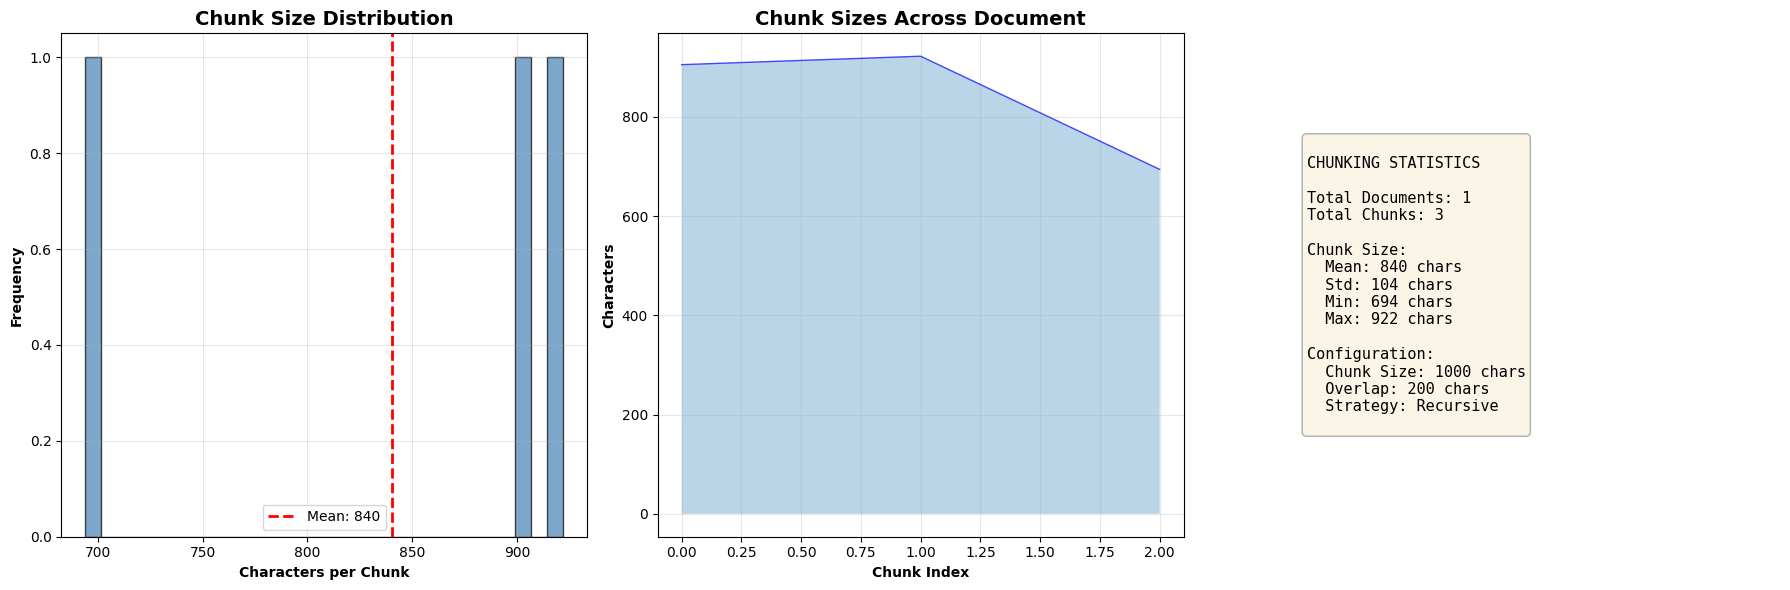

✅ Chunking analysis saved: C:\Python\ML Intro\Projects\Chat with Documents\results\plots\chunking_analysis.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Analyze chunk sizes
chunk_sizes = [len(c.page_content) for c in chunks]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Chunk size distribution
ax1 = axes[0]
ax1.hist(chunk_sizes, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(np.mean(chunk_sizes), color='red', linestyle='--',
           linewidth=2, label=f'Mean: {np.mean(chunk_sizes):.0f}')
ax1.set_title('Chunk Size Distribution', fontweight='bold', fontsize=14)
ax1.set_xlabel('Characters per Chunk', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Chunk sizes over document
ax2 = axes[1]
ax2.plot(range(len(chunk_sizes)), chunk_sizes, 'b-', linewidth=1, alpha=0.7)
ax2.fill_between(range(len(chunk_sizes)), chunk_sizes, alpha=0.3)
ax2.set_title('Chunk Sizes Across Document', fontweight='bold', fontsize=14)
ax2.set_xlabel('Chunk Index', fontweight='bold')
ax2.set_ylabel('Characters', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Summary statistics
ax3 = axes[2]
ax3.axis('off')
stats_text = f"""
CHUNKING STATISTICS

Total Documents: {len(all_documents)}
Total Chunks: {len(chunks)}

Chunk Size:
  Mean: {np.mean(chunk_sizes):.0f} chars
  Std: {np.std(chunk_sizes):.0f} chars
  Min: {np.min(chunk_sizes)} chars
  Max: {np.max(chunk_sizes)} chars

Configuration:
  Chunk Size: 1000 chars
  Overlap: 200 chars
  Strategy: Recursive
"""
ax3.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
        verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
save_path = project_dir / 'results' / 'plots' / 'chunking_analysis.png'
plt.savefig(str(save_path), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Chunking analysis saved: {save_path}")

In [14]:
from langchain_community.embeddings import HuggingFaceEmbeddings
import time

print("🔢 Creating embeddings...")
print("="*70)
print("   Model: sentence-transformers/all-MiniLM-L6-v2")
print("   Embedding dimension: 384")
print("   This model is FREE and runs locally!")
print("="*70)

# Load embedding model
print("\n🔄 Loading embedding model...")
start_time = time.time()

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

load_time = time.time() - start_time
print(f"✅ Embedding model loaded in {load_time:.1f}s")

# Test embeddings
print("\n🧪 Testing embeddings...")
test_texts = [
    "What is machine learning?",
    "Artificial intelligence applications",
    "Deep learning neural networks"
]

start_time = time.time()
test_embeddings = embeddings.embed_documents(test_texts)
embed_time = time.time() - start_time

print(f"✅ Test embeddings created!")
print(f"   Number of texts: {len(test_texts)}")
print(f"   Embedding shape: ({len(test_embeddings)}, {len(test_embeddings[0])})")
print(f"   Embedding time: {embed_time:.2f}s")
print(f"   Time per embedding: {embed_time/len(test_texts)*1000:.1f}ms")

🔢 Creating embeddings...
   Model: sentence-transformers/all-MiniLM-L6-v2
   Embedding dimension: 384
   This model is FREE and runs locally!

🔄 Loading embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3909.76it/s]


✅ Embedding model loaded in 5.9s

🧪 Testing embeddings...
✅ Test embeddings created!
   Number of texts: 3
   Embedding shape: (3, 384)
   Embedding time: 0.35s
   Time per embedding: 115.4ms


📊 Visualizing embeddings...


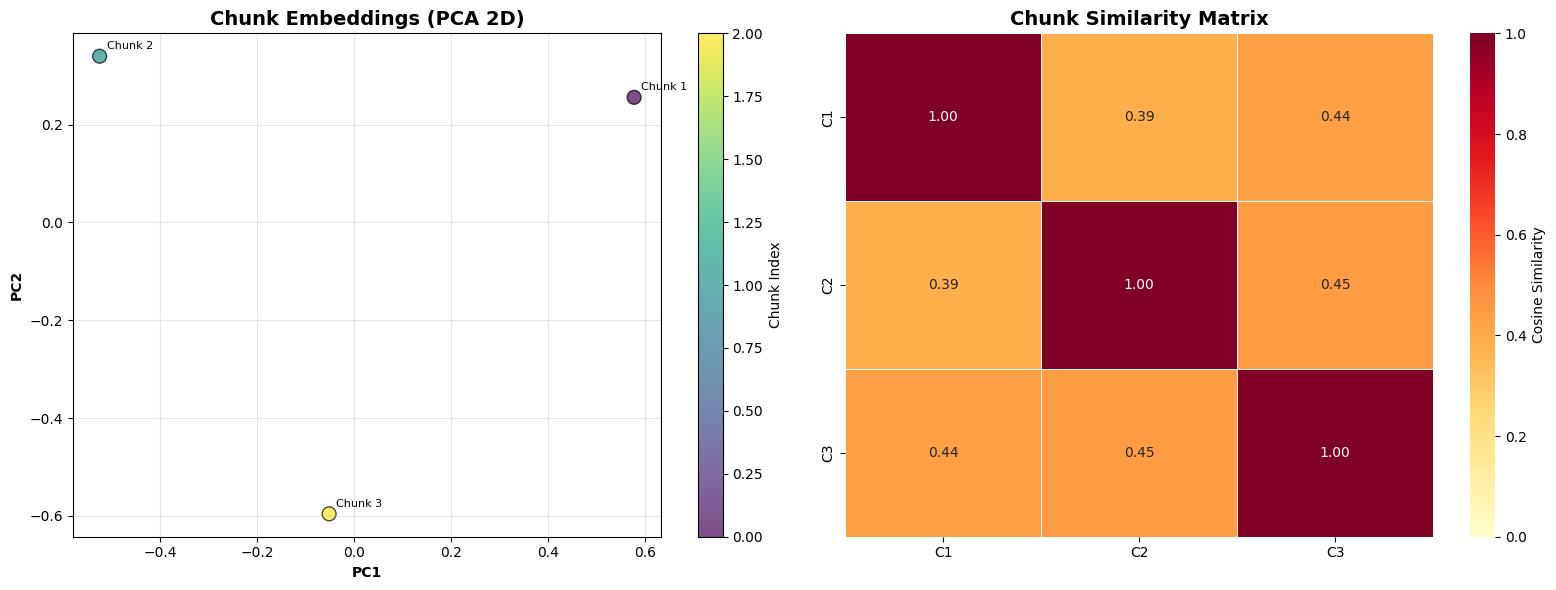

✅ Embedding visualization saved: C:\Python\ML Intro\Projects\Chat with Documents\results\plots\embeddings_visualization.png


In [16]:
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("📊 Visualizing embeddings...")

# Create embeddings for sample chunks
sample_texts = [chunk.page_content[:200] for chunk in chunks[:20]]
sample_embeddings = embeddings.embed_documents(sample_texts)
sample_embeddings = np.array(sample_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. PCA visualization
ax1 = axes[0]
pca = PCA(n_components=2)
reduced = pca.fit_transform(sample_embeddings)

scatter = ax1.scatter(
    reduced[:, 0], reduced[:, 1],
    c=range(len(reduced)),
    cmap='viridis',
    s=100, alpha=0.7, edgecolors='black'
)

for i, (x, y) in enumerate(reduced):
    ax1.annotate(f'Chunk {i+1}', (x, y),
                textcoords="offset points",
                xytext=(5, 5), fontsize=8)

plt.colorbar(scatter, ax=ax1, label='Chunk Index')
ax1.set_title('Chunk Embeddings (PCA 2D)', fontweight='bold', fontsize=14)
ax1.set_xlabel('PC1', fontweight='bold')
ax1.set_ylabel('PC2', fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Cosine similarity heatmap
ax2 = axes[1]
sim_matrix = cosine_similarity(sample_embeddings)
n = len(sim_matrix)
sns_data = pd.DataFrame(
    sim_matrix,
    index=[f'C{i+1}' for i in range(n)],
    columns=[f'C{i+1}' for i in range(n)]
)

import seaborn as sns
sns.heatmap(
    sns_data,
    ax=ax2,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Cosine Similarity'}
)
ax2.set_title('Chunk Similarity Matrix', fontweight='bold', fontsize=14)

plt.tight_layout()
save_path = project_dir / 'results' / 'plots' / 'embeddings_visualization.png'
plt.savefig(str(save_path), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Embedding visualization saved: {save_path}")

In [20]:
import pickle

print("💾 Saving processed data...")

# Save chunks
chunks_path = project_dir / 'data' / 'processed' / 'chunks.pkl'
with open(str(chunks_path), 'wb') as f:
    pickle.dump(chunks, f)

print(f"✅ Chunks saved: {chunks_path}")
print(f"   Number of chunks: {len(chunks)}")

# Save config
config = {
    'chunk_size': 1000,
    'chunk_overlap': 200,
    'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2',
    'embedding_dim': 384,
    'llm_model': 'openai/gpt-oss-120b',
    'total_chunks': len(chunks),
    'total_docs': len(all_documents)
}

config_path = project_dir / 'config.json'
with open(str(config_path), 'w') as f:
    json.dump(config, f, indent=4)

print(f"✅ Config saved: {config_path}")
print(f"\n📝 Config:")
for k, v in config.items():
    print(f"   {k}: {v}")

💾 Saving processed data...
✅ Chunks saved: C:\Python\ML Intro\Projects\Chat with Documents\data\processed\chunks.pkl
   Number of chunks: 3
✅ Config saved: C:\Python\ML Intro\Projects\Chat with Documents\config.json

📝 Config:
   chunk_size: 1000
   chunk_overlap: 200
   embedding_model: sentence-transformers/all-MiniLM-L6-v2
   embedding_dim: 384
   llm_model: openai/gpt-oss-120b
   total_chunks: 3
   total_docs: 1


In [19]:
print("\n" + "="*70)
print("🎉 WEEK 1 COMPLETE!")
print("="*70)

print("\n✅ Completed Tasks:")
print("   ✓ Libraries installed")
print("   ✓ Project structure created")
print("   ✓ Groq API configured and tested")
print("   ✓ Documents loaded")
print("   ✓ Text chunking implemented")
print("   ✓ Embeddings created (HuggingFace)")
print("   ✓ Embedding visualization done")
print("   ✓ Data saved for Week 2")

print("\n📊 Week 1 Stats:")
print(f"   Documents loaded: {len(all_documents)}")
print(f"   Chunks created: {len(chunks)}")
print(f"   Embedding dim: 384")
print(f"   Embedding model: all-MiniLM-L6-v2")

print("\n📁 Files Created:")
print("   • config.json")
print("   • data/processed/chunks.pkl")
print("   • results/plots/chunking_analysis.png")
print("   • results/plots/embeddings_visualization.png")

print("\n🎯 Next Steps (Week 2):")
print("   1. Build FAISS vector database")
print("   2. Implement similarity search")
print("   3. Test retrieval quality")
print("   4. Optimize search parameters")



🎉 WEEK 1 COMPLETE!

✅ Completed Tasks:
   ✓ Libraries installed
   ✓ Project structure created
   ✓ Groq API configured and tested
   ✓ Documents loaded
   ✓ Text chunking implemented
   ✓ Embeddings created (HuggingFace)
   ✓ Embedding visualization done
   ✓ Data saved for Week 2

📊 Week 1 Stats:
   Documents loaded: 1
   Chunks created: 3
   Embedding dim: 384
   Embedding model: all-MiniLM-L6-v2

📁 Files Created:
   • config.json
   • data/processed/chunks.pkl
   • results/plots/chunking_analysis.png
   • results/plots/embeddings_visualization.png

🎯 Next Steps (Week 2):
   1. Build FAISS vector database
   2. Implement similarity search
   3. Test retrieval quality
   4. Optimize search parameters


In [ ]:
import os
from pathlib import Path

project_dir = Path(r'C:\Python\Projects\Chat With Documents')

print("="*70)
print("🔍 COMPLETE FILE VERIFICATION")
print("="*70)

expected_files = {
    'Config': 'config.json',
    'Chunks': 'data/processed/chunks.pkl',
    'Metadata': 'data/processed/metadata.json',
    'Chunking Plot': 'results/plots/chunking_analysis.png',
    'Embeddings Plot': 'results/plots/embeddings_visualization.png',
}

all_saved = True
for name, rel_path in expected_files.items():
    full_path = os.path.join(str(project_dir), rel_path)
    
    if os.path.exists(full_path):
        size = os.path.getsize(full_path)
        if size >= 1024 * 1024:
            size_str = f"{size/(1024*1024):.1f} MB"
        elif size >= 1024:
            size_str = f"{size/1024:.1f} KB"
        else:
            size_str = f"{size} bytes"
        print(f"   ✅ {name}: {size_str}")
    else:
        print(f"   ❌ {name}: NOT FOUND")
        print(f"      Expected at: {full_path}")
        all_saved = False

print("="*70)
if all_saved:
    print("🎉 ALL FILES SAVED SUCCESSFULLY!")
else:
    print("⚠️  Some files missing - check errors above")
print("="*70)

🔍 COMPLETE FILE VERIFICATION
   ✅ Config: 344 bytes
   ✅ Chunks: 2.9 KB
   ✅ Metadata: 199 bytes
   ✅ Chunking Plot: 259.6 KB
   ✅ Embeddings Plot: 170.1 KB
🎉 ALL FILES SAVED SUCCESSFULLY!

🚀 Ready for Week 2!
